### Building Chatbot With Multiple Tools Using Langgraph

#### Aim
Create a chatbot with tool capabilities from arxiv, wikipedia search and some functions

In [1]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

In [3]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki_tool = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
api_wrapper_arxiv = ArxivAPIWrapper(max_results=2,doc_content_chars_max=500)
arxiv_tool = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)

In [5]:
print(wiki_tool.name)
print(arxiv_tool.name)

wikipedia
arxiv


In [7]:
arxiv_tool.invoke("Graph Neural Networks")

'Published: 2023-06-26\nTitle: The Deep Arbitrary Polynomial Chaos Neural Network or how Deep Artificial Neural Networks could benefit from Data-Driven Homogeneous Chaos Theory\nAuthors: Sergey Oladyshkin, Timothy Praditia, Ilja Kröker, Farid Mohammadi, Wolfgang Nowak, Sebastian Otte\nSummary: Artificial Intelligence and Machine learning have been widely used in various fields of mathematical computing, physical modeling, computational science, communication science, and stochastic analysis. Approac'

In [6]:
wiki_tool.invoke("What is LangGraph?")

'Page: WhatsApp\nSummary: WhatsApp Messenger, commonly known simply as WhatsApp, is an American social media, instant messaging (IM), and Voice over IP (VoIP) service accessible via desktop and mobile app. Owned by Meta Platforms, the service allows users to send text messages, voice messages, and video messages, make voice and video calls, and share images, documents, user locations, and other content. The service requires a cellular mobile telephone number to register. WhatsApp was launched in M'

In [9]:
from dotenv import load_dotenv
load_dotenv()
import os

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")

In [ ]:
## Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults
tavily_tool = TavilySearchResults()
print(tavily_tool.name)
tavily_tool.invoke("Latest research on Graph Neural Networks")


tavily_search_results_json


[{'title': 'AI trends in 2025: Graph Neural Networks - AssemblyAI',
  'url': 'https://www.assemblyai.com/blog/ai-trends-graph-neural-networks',
  'content': 'A recent bibliometric study systematically analysed this research trend, revealing an exponential growth of published research involving GNNs, with a striking +447% average annual increase in the period 2017-2019. The State of AI Report 2021 further confirmed Graph Neural Network to be the keyword in AI research publications “with the largest increase in usage from 2019 to 2020”.\n\nWe can also examine the versatility of Graph Neural Networks by looking at their impact across different domains of application. The following figure aims at illustrating the distribution of GNN papers across 22 categories. [...] What is the current role of GNNs in the broader AI research landscape? Let’s first take a look at some statistics revealing how GNNs have seen a spectacular rise within the research community.\n\n## Graph Neural Networks in th

In [11]:
### Combine all the tools in the list
tools = [wiki_tool,arxiv_tool,tavily_tool]

In [13]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model_name="gpt-4")

llm_with_tools = llm.bind_tools(tools)

In [14]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([
    HumanMessage(content="Provide me a summary of Graph Neural Networks based on the latest research papers and a brief overview from Wikipedia.")
])



AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 237, 'total_tokens': 253, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4-0613', 'system_fingerprint': None, 'id': 'chatcmpl-D0dhNvSvjvoAnT9KVGyypdAWx3Cch', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019be34c-1518-7623-9f48-d02a75f2e56f-0', tool_calls=[{'name': 'wikipedia', 'args': {'query': 'Graph Neural Networks'}, 'id': 'call_vv2vc3MU5RudrDrwrSUYaYF7', 'type': 'tool_call'}], usage_metadata={'input_tokens': 237, 'output_tokens': 16, 'total_tokens': 253, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [15]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent AI News'},
  'id': 'call_YHF2JUwc5m7pdZ1TGirn6fpj',
  'type': 'tool_call'}]

In [16]:
from langgraph.graph.message import add_messages, AnyMessage
from typing import Annotated
from pydantic import BaseModel

class state(BaseModel):
    messages: Annotated[list[AnyMessage],add_messages]

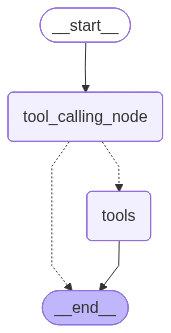

In [21]:
### Entire Chatbot With LangGraph
from IPython.display import Image,display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

# Node Definitions

def tool_calling_node(state:state):
    return {"messages": [llm_with_tools.invoke(state.messages)]}

# Build Graph
builder = StateGraph(state)
builder.add_node("tool_calling_node", tool_calling_node)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_node")
builder.add_conditional_edges(
    "tool_calling_node",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)

builder.add_edge("tools", END)

graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [22]:
messages=graph.invoke({"messages":HumanMessage(content="1706.03762")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (call_yxymUWb2rCJPb1S1b1AEnNCg)
 Call ID: call_yxymUWb2rCJPb1S1b1AEnNCg
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base


In [23]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me the top 10 recent AI news till 22nd Jan 2026")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news till 22nd Jan 2026
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json.sharedInstance (call_1Q37U4bYMeaoIf8Az7a37R3i)
 Call ID: call_1Q37U4bYMeaoIf8Az7a37R3i
  Args:
    query: AI news till 22nd Jan 2026
================================= Tool Message =================================
Name: tavily_search_results_json.sharedInstance

Error: tavily_search_results_json.sharedInstance is not a valid tool, try one of [wikipedia, arxiv, tavily_search_results_json].


In [24]:
messages=graph.invoke({"messages":HumanMessage(content="What is machine learning")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================
Tool Calls:
  wikipedia (call_Yhi9DOnACa5cFe92kQgQ0q8Z)
 Call ID: call_Yhi9DOnACa5cFe92kQgQ0q8Z
  Args:
    query: Machine learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalise to unseen data, and thus perform tasks without explicit instructions. Within a subdiscipline in machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
ML fi
